In [ ]:
# Cell 1: Generating the curves
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.stats import norm
from tqdm import tqdm
import matplotlib.gridspec as gridspec
import warnings

# General parameters
n_curves = 200
n_points = 500

# Mid-point grid: (k - 1/2) / n_points for k = 1, ..., n_points
# Required by the theorem for the inner product computed via a Riemann sum
t = (np.arange(1, n_points + 1) - 0.5) / n_points  # mid-points on [0, 1]

# Null hypothesis: theoretical mean equal to zero
def mean_null(t):
    return np.zeros_like(t)

# mu_0 being tested (used to define X_i = W_i - mu_0)
mu_0 = mean_null(t)

def generate_curves(mean_func, n_curves, t, n_basis=10, sigma_noise=0.05,
                    seed=None, sigma_coeff=0.5):
    """
    Generates curves W_i = mean_func(t) + smooth random part + noise.
    X_i = W_i - mu_0 is computed outside this function.

    Parameters
    ----------
    mean_func  : function t -> array, the true theoretical mean
    n_curves   : number of curves
    t          : grid (mid-points recommended)
    n_basis    : number of sine/cosine pairs
    sigma_noise: standard deviation of the white noise
    sigma_coeff: standard deviation of the random Fourier coefficients
    """
    if seed is not None:
        np.random.seed(seed)

    # Fourier basis: sin(pi*k*t) and cos(pi*k*t) for k = 1, ..., n_basis
    basis = []
    for k in range(1, n_basis + 1):
        basis.append(.25*np.sin(np.pi * k * t))
        basis.append(.25*np.cos(np.pi * k * t))
    basis = np.array(basis).T  # (n_points, 2*n_basis)

    mu = mean_func(t)
    curves = np.zeros((n_curves, n_points))
    for i in range(n_curves):
        coeff = np.random.normal(0, sigma_coeff, size=2 * n_basis)
        noise = np.random.normal(0, sigma_noise, size=n_points)
        curves[i] = mu + basis @ coeff + noise
    return curves

# Generation (seed fixed -> fully reproducible)
curves = generate_curves(mean_null, n_curves, t,
                         n_basis=10, sigma_noise=0.05, seed=42, sigma_coeff=1)

# X_i = W_i - mu_0  (here mu_0 = 0, so X = curves)
X = curves - mu_0  # shape (n_curves, n_points)

# Empirical mean of X (for visualization only — not used in the test)
X_bar = np.mean(X, axis=0)

print(f"Grid: mid-points from 0 to 1, n_points={n_points}")
print(f"Generated curves X_i: {X.shape}")
print(f"Empirical mean X_bar: {X_bar.shape}")

Grid: mid-points from 0 to 1, n_points=500
Generated curves X_i: (200, 500)
Empirical mean X_bar: (500,)


k_n (retained eigenvalues) : 200
Trace Gamma_n (sum of lambda_j) : 303.673802


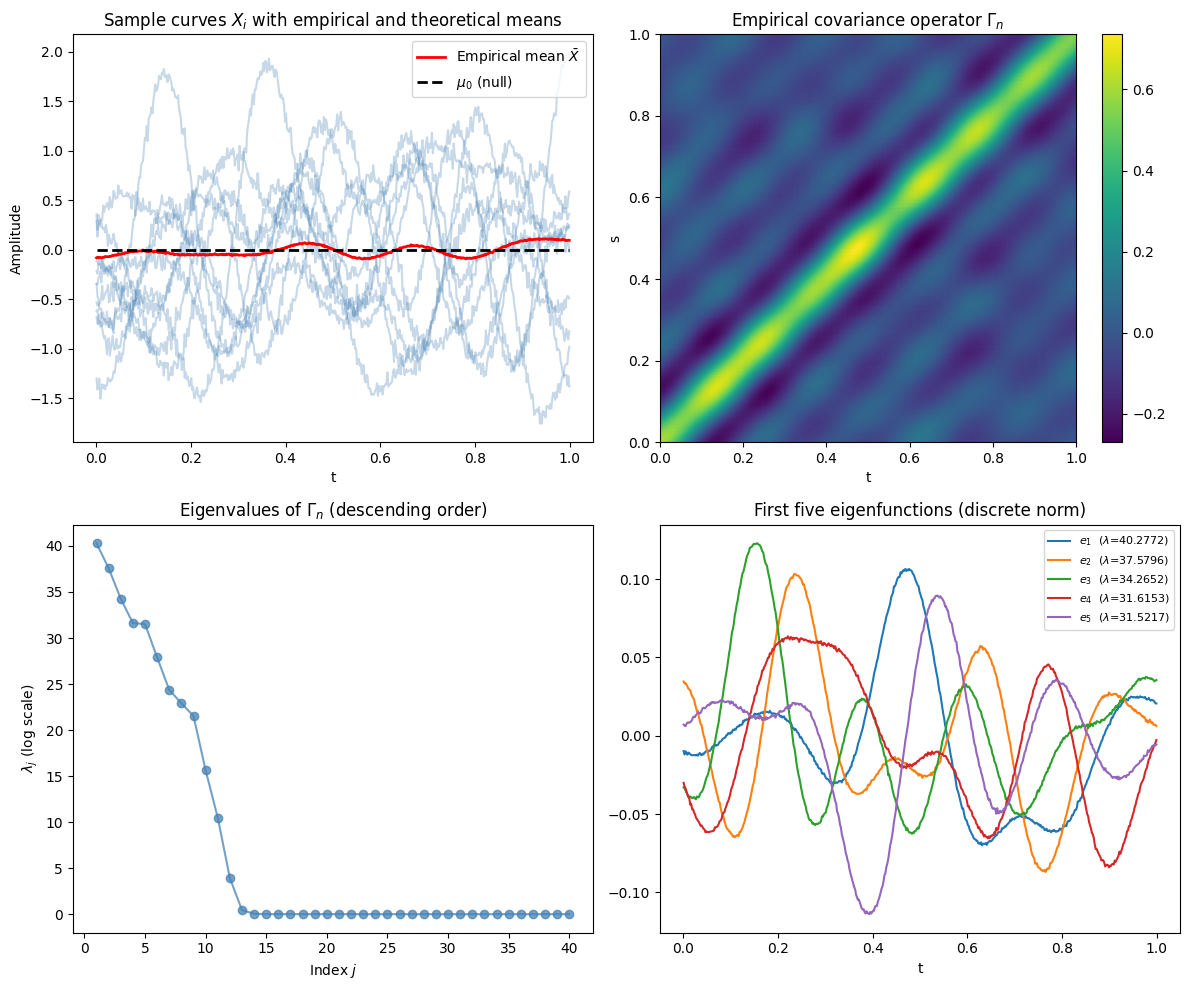

In [ ]:
# Cell 2: Covariance operator Gamma_n and its eigenvectors

n = X.shape[0]
dt = 1.0 / n_points  # mid-points grid step

# Gamma_n = (1/n) * sum_i X_i (x) X_i
Gamma_n = (X.T @ X) / n   # (n_points x n_points)

# k_n = maximal rank of Gamma_n = min(n, n_points)
k_n = min(n, n_points)

# Spectral decomposition — only the k_n largest eigenvalues
# eigh sorts in ascending order -> take the last k_n indices
eigvals, eigvecs = eigh(
    Gamma_n,
    subset_by_index=[n_points - k_n, n_points - 1]
)
# Sort in descending order
idx     = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]        # (k_n,)  — discrete norm: sum e_j^2 = 1
eigvecs = eigvecs[:, idx]     # (n_points, k_n)

print(f"k_n (retained eigenvalues) : {k_n}")
print(f"Trace Gamma_n (sum of lambda_j) : {eigvals.sum():.6f}")

# -- Visualization -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Sample curves + means
ax = axes[0, 0]
for i in range(min(10, n)):
    ax.plot(t, X[i], alpha=0.3, color='steelblue')
ax.plot(t, X_bar, 'r-', linewidth=2, label=r'Empirical mean $\bar{X}$')
ax.plot(t, mu_0,  'k--', linewidth=2, label=r'$\mu_0$ (null)')
ax.set_title(r'Sample curves $X_i$ with empirical and theoretical means')
ax.set_xlabel('t'); ax.set_ylabel('Amplitude')
ax.legend()

# 2. Covariance operator (heatmap)
ax = axes[0, 1]
im = ax.imshow(Gamma_n, extent=[0, 1, 0, 1], origin='lower',
               aspect='auto', cmap='viridis')
fig.colorbar(im, ax=ax)
ax.set_title(r'Empirical covariance operator $\Gamma_n$')
ax.set_xlabel('t'); ax.set_ylabel('s')

# 3. Eigenvalues
ax = axes[1, 0]
k_show = min(40, k_n)
ax.plot(range(1, k_show + 1), eigvals[:k_show], 'o-', color='steelblue', alpha=0.75)
ax.set_title(r'Eigenvalues of $\Gamma_n$ (descending order)')
ax.set_xlabel('Index $j$')
ax.set_ylabel(r'$\lambda_j$ (log scale)')

# 4. First 5 eigenfunctions (discrete norm sum e_j^2 = 1)
ax = axes[1, 1]
for k in range(min(5, k_n)):
    ax.plot(t, eigvecs[:, k], label=fr'$e_{k+1}$  ($\lambda$={eigvals[k]:.4f})')
ax.set_title('First five eigenfunctions (discrete norm)')
ax.set_xlabel('t')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('curves.png', dpi=150, bbox_inches='tight')
plt.savefig('curves.pdf', dpi=150, bbox_inches='tight')
plt.show()

Monte Carlo: 100%|██████████| 59994/59994 [2:12:36<00:00,  7.54rep/s]


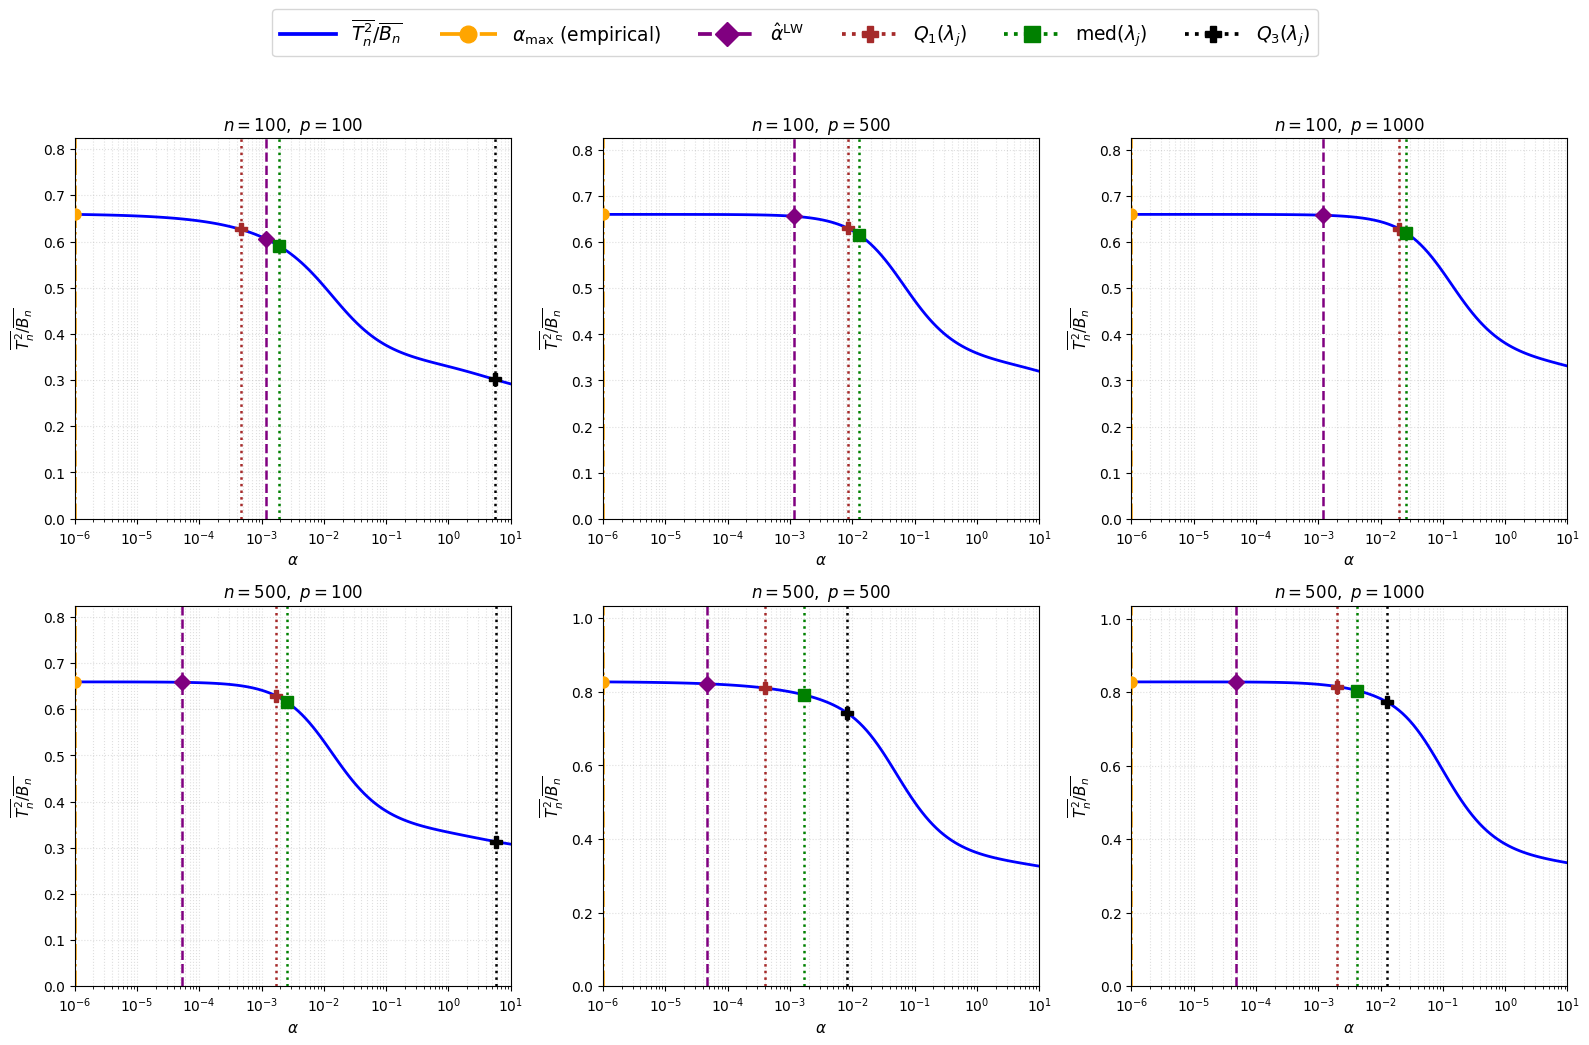

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm

# ============================================================================
# Global parameters
# ============================================================================
np.random.seed(42)

J = 10
sigma_xi = 1.0
sigma_eps = 0.05
delta = 0.05
C_const = (2/9) * np.e**3
c_delta = np.log(C_const / delta)

M = 9999
n_vals = [100, 500]
p_vals = [100, 500, 1000]

alpha_grid = np.logspace(-6, 1, 120)


# ============================================================================
# Functions
# ============================================================================

def generate_curves(n, p, sigma_xi, sigma_eps, J, shift=0.0):
    t = (np.arange(1, p+1) - 0.5) / p
    Phi = np.zeros((p, 2*J))
    for j in range(1, J+1):
        Phi[:, 2*j-2] = 0.25 * np.sin(np.pi * j * t)
        Phi[:, 2*j-1] = 0.25 * np.cos(np.pi * j * t)
    xi  = np.random.randn(n, 2*J) * sigma_xi
    eps = np.random.randn(n, p)   * sigma_eps
    Z   = xi @ Phi.T + eps - shift
    return Z


def compute_covariance(Z):
    n, p = Z.shape
    U, s, Vt = np.linalg.svd(Z / np.sqrt(n), full_matrices=False)
    eigvals = s**2
    return eigvals, Vt


def compute_T2(Z, eigvals, Vt, alpha):
    n = Z.shape[0]
    Z_bar = Z.mean(axis=0)
    projs = Vt @ Z_bar
    return n * np.sum(projs**2 / (eigvals + alpha))


def compute_bound(eigvals, alpha, c_delta):
    w         = eigvals / (eigvals + alpha)
    Theta1    = np.sum(w)
    Theta2    = np.sqrt(np.sum(w**2))
    Theta_inf = np.max(w)
    return Theta1 + 2*Theta2*(np.sqrt(c_delta) + (Theta_inf/Theta2)*c_delta)


def compute_alpha_LW(eigvals, n):
    lam   = eigvals
    K     = len(lam)
    tr_G  = np.sum(lam)
    tr_G2 = np.sum(lam**2)
    num   = (1.0/n) * (tr_G2 + tr_G**2)
    den   = (n + 1 - 2.0/K) * (tr_G2 - tr_G**2 / K)
    return num / den if den > 0 else np.nan


# ============================================================================
# Monte Carlo simulation
# ============================================================================

results = {}
total_runs = len(n_vals) * len(p_vals) * M
pbar = tqdm(total=total_runs, desc="Monte Carlo", unit="rep")

for n in n_vals:
    for p in p_vals:
        T2_acc   = np.zeros(len(alpha_grid))
        B_acc    = np.zeros(len(alpha_grid))
        LW_acc   = []
        Q1_acc   = []
        med_acc  = []
        Q3_acc   = []

        for m in range(M):
            Z = generate_curves(n, p, sigma_xi, sigma_eps, J, shift=0.0)
            eigvals, Vt = compute_covariance(Z)

            for k, alpha in enumerate(alpha_grid):
                T2_acc[k] += compute_T2(Z, eigvals, Vt, alpha)
                B_acc[k]  += compute_bound(eigvals, alpha, c_delta)

            LW_acc.append(compute_alpha_LW(eigvals, n))
            Q1_acc.append(np.percentile(eigvals, 25))
            med_acc.append(np.median(eigvals))
            Q3_acc.append(np.percentile(eigvals, 95))

            pbar.update(1)

        T2_mean    = T2_acc / M
        B_mean     = B_acc  / M
        ratio_mean = T2_mean / B_mean

        results[(n, p)] = {
            'ratio_mean':  ratio_mean,
            'alpha_max':   alpha_grid[np.argmax(ratio_mean)],
            'alpha_LW':    np.nanmean(LW_acc),
            'alpha_Q1':    np.nanmean(Q1_acc),
            'alpha_med':   np.nanmean(med_acc),
            'alpha_Q3':    np.nanmean(Q3_acc),
        }

pbar.close()


# ============================================================================
# Plotting
# ============================================================================

# (key, label, color, linestyle, marker)
candidates = [
    ('alpha_max', r'$\alpha_{\max}$ (empirical)',   'orange', '-.', 'o'),
    ('alpha_LW',  r'$\hat\alpha^{\mathrm{LW}}$',    'purple', '--', 'D'),
    ('alpha_Q1',  r'$Q_1(\lambda_j)$',              'brown',  ':',  'P'),
    ('alpha_med', r'$\mathrm{med}(\lambda_j)$',     'green',  ':',  's'),
    ('alpha_Q3',  r'$Q_3(\lambda_j)$',              'black',  ':',  'P'),
]

fig, axes = plt.subplots(len(n_vals), len(p_vals), figsize=(16, 10))

for i, n in enumerate(n_vals):
    for j, p in enumerate(p_vals):
        ax  = axes[i, j]
        res = results[(n, p)]
        ratio = res['ratio_mean']

        ax.plot(alpha_grid, ratio, 'b-', lw=2)

        for key, label, color, ls, marker in candidates:
            a_val = res[key]
            r_val = np.interp(a_val, alpha_grid, ratio)
            ax.axvline(a_val, color=color, ls=ls, lw=1.8)
            ax.plot(a_val, r_val, marker=marker, color=color, ms=8, zorder=5)

        ax.set_xscale('log')
        ax.set_xlim(alpha_grid[0], alpha_grid[-1])
        ax.set_ylim(0, min(ratio.max()*1.25, 1.05))
        ax.set_title(f'$n={n},\\ p={p}$', fontsize=12)
        ax.set_xlabel(r'$\alpha$', fontsize=11)
        ax.set_ylabel(r'$\overline{T_n^2} / \overline{B_n}$', fontsize=11)
        ax.grid(True, which='both', ls=':', alpha=0.4)

# -- Legend size control ------------------------------------------------
# Multiply this to scale the whole legend (text, markers, line widths) up
# or down. E.g. LEGEND_SCALE = 3 instead of 1.5 roughly doubles the size.
LEGEND_SCALE = 1.5

legend_fontsize = 9 * LEGEND_SCALE
legend_lw       = 1.8 * LEGEND_SCALE
legend_ms       = 8 * LEGEND_SCALE

# -- Single shared legend (no numeric values), horizontal ribbon on top ------
legend_handles = [
    Line2D([0], [0], color='b', lw=legend_lw, label=r'$\overline{T_n^2}/\overline{B_n}$')
]
for key, label, color, ls, marker in candidates:
    legend_handles.append(
        Line2D([0], [0], color=color, ls=ls, marker=marker,
               lw=legend_lw, ms=legend_ms, label=label)
    )

fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 1.05), ncol=len(legend_handles),
           fontsize=legend_fontsize, frameon=True, handlelength=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('ratio_selected_alphas.pdf', bbox_inches='tight')
plt.savefig('ratio_selected_alphas.png', dpi=150, bbox_inches='tight')
plt.show()